In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#df = df[df['job_posted_date'].dt.year == 2025 ]

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


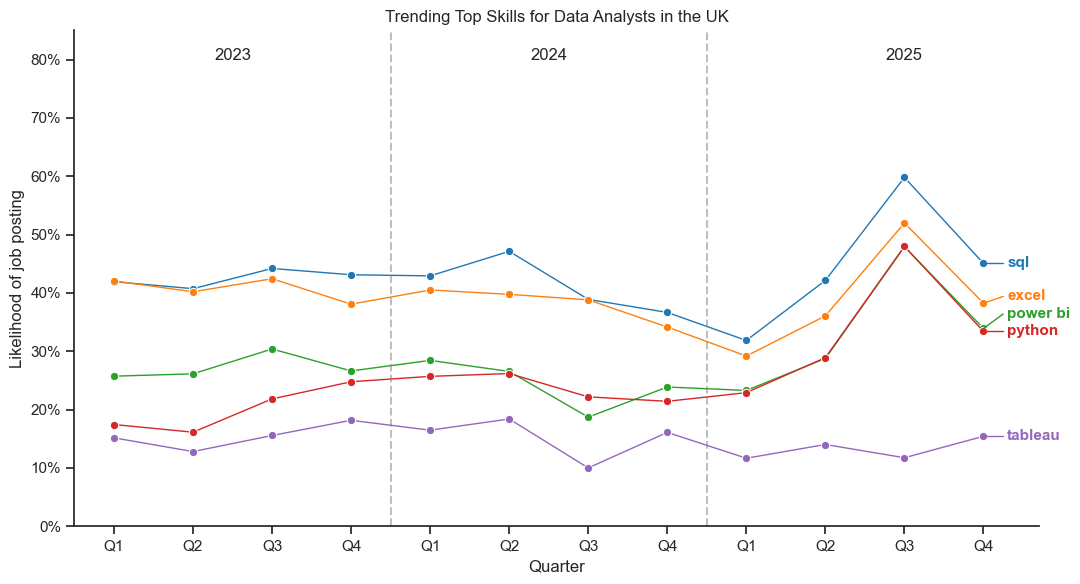

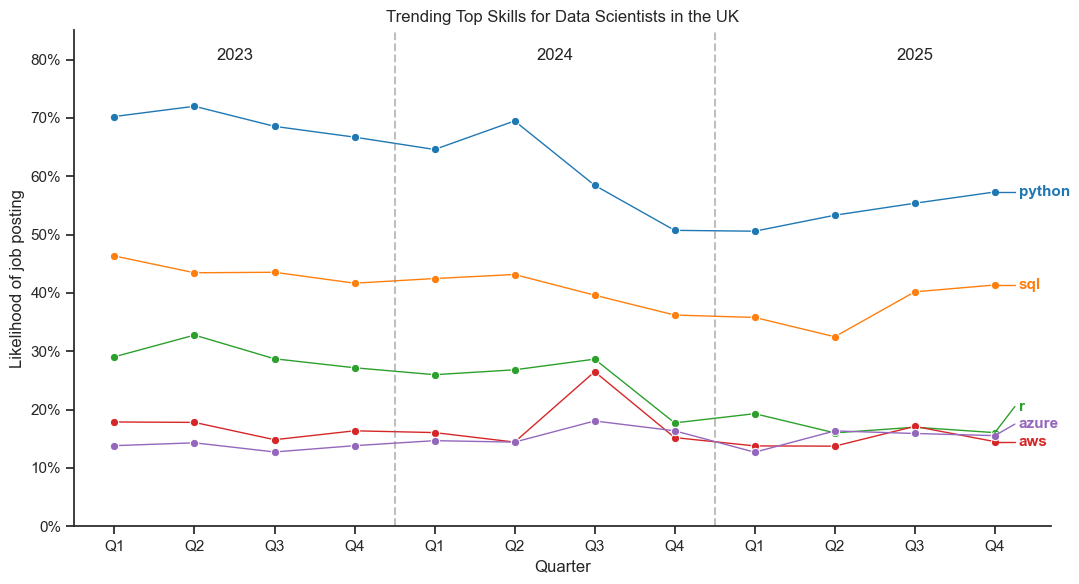

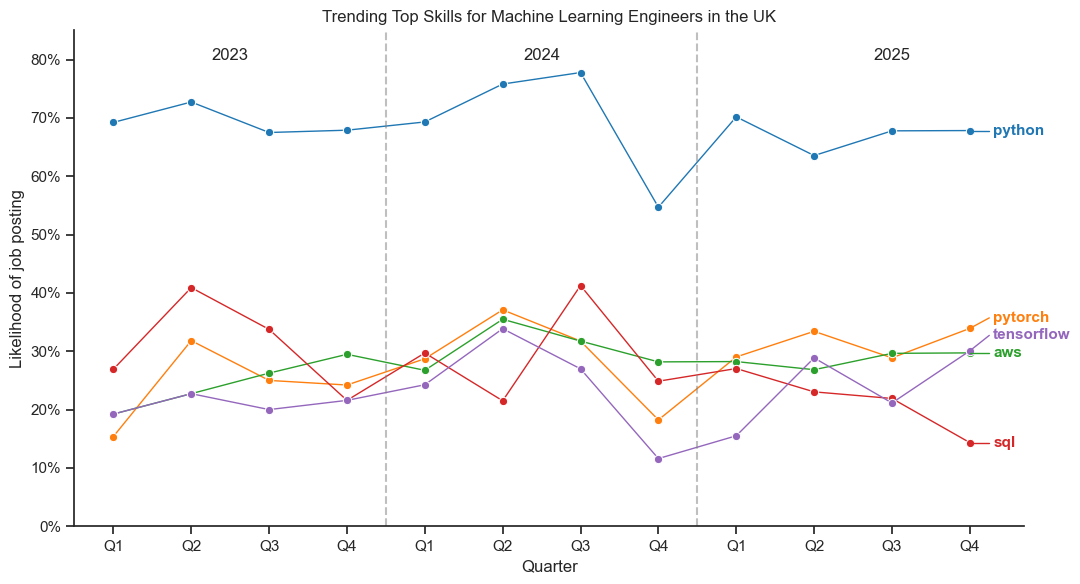

In [3]:
from matplotlib.ticker import PercentFormatter

years_name = ['2023', '2024', '2025']
years = [2023, 2024, 2025]
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
#establishing list to iterate through and creating new columns for months and years of postings
job_list = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']
df['job_posted_year'] = df['job_posted_date'].dt.year
df['job_posted_month_num'] = df['job_posted_date'].dt.month
df['job_posted_quarter'] = 4*abs(2023 - df['job_posted_date'].dt.year) + df['job_posted_date'].dt.quarter
    
df_jobs = [
    df[
        (df['job_title_short'] == job)
        & (df['job_country'] == 'United Kingdom')
    ]
    for job in job_list
]

df_jobs_exploded = [
    i.explode('job_skills').dropna(subset=['job_skills'])
    for i in df_jobs
]

#creates figures
for job, df_job_explode, df_job in zip(job_list, df_jobs_exploded, df_jobs):
    pivot_skill_counts = df_job_explode.pivot_table(
        index='job_posted_quarter',
        columns='job_skills',
        aggfunc='size',
        fill_value=0
    )

    pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
    pivot_skill_counts = pivot_skill_counts[
        pivot_skill_counts.loc['total'].sort_values(ascending=False).index
    ].iloc[:, :5]

    pivot_totals = df_job.groupby('job_posted_quarter').size()

    pivot_skill_perc = (
        pivot_skill_counts
        .iloc[:12]
        .div(pivot_totals / 100, axis=0)
        .reset_index()
        .drop(columns='job_posted_quarter')
    )

    sns.set_theme(style='ticks')

    sns.lineplot(
        data=pivot_skill_perc,
        dashes=False,
        legend='full',
        palette='tab10',
        linewidth=1,
        marker='o',
        markersize=6
    )

    sns.despine()
    plt.title(f"Trending Top Skills for {job}s in the UK")
    plt.ylabel('Likelihood of job posting')
    plt.xlabel('Quarter')
    plt.legend().remove()
    plt.ylim(0, 85)
    plt.xlim(-0.5, 11.7)

    plt.axvline(3.5, color='grey', linestyle='--', alpha=0.5)
    plt.axvline(7.5, color='grey', linestyle='--', alpha=0.5)
    #plt.axvline(11, color='grey', linestyle='--', alpha=0.5)

    ax = plt.gca()
    ax.text(1.5, 80, '2023', ha='center')
    ax.text(5.5, 80, '2024', ha='center')
    ax.text(10, 80, '2025', ha='center')
    ax.set_xlim(-0.5, 11.7)
    ax.figure.set_size_inches(11, 6)

    quarters = ['Q1', 'Q2', 'Q3', 'Q4'] * 3
    plt.xticks(range(12), quarters)

    colors = sns.color_palette("tab10", len(pivot_skill_perc.columns))

    end_labels = []

    for j, skill in enumerate(pivot_skill_perc.columns):
        actual_y = pivot_skill_perc[skill].iloc[-1]

        end_labels.append({
            "skill": skill,
            "actual_y": actual_y,
            "label_y": actual_y,
            "color": colors[j]
        })

    end_labels = sorted(end_labels, key=lambda x: x["label_y"])

    min_gap = 3

    for i in range(1, len(end_labels)):
        if end_labels[i]["label_y"] - end_labels[i - 1]["label_y"] < min_gap:
            end_labels[i]["label_y"] = end_labels[i - 1]["label_y"] + min_gap

    for item in end_labels:
        plt.plot(
            [11, 11.25],
            [item["actual_y"], item["label_y"]],
            color=item["color"],
            lw=1
        )

        plt.text(
            11.3,
            item["label_y"],
            item["skill"],
            color=item["color"],
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.tight_layout()
    plt.show()

In [ ]:
# df_filtered_quarters = [
#     dataframe[ 
#     dataframe['job_posted_quarter'] == quarter
#     ]
#     for dataframe in df_filtered_years
#     for quarter in quarters
# ]

# df_quarters = [
#     quarter_df.explode('job_skills').dropna(subset=['job_skills'])
#     for quarter_df in df_filtered_quarters
#]






# #creates figures for DA
# for (year, year_filtered, year_name) in zip(df_years[:3], df_filtered_years[:3], years_name):
#   pivot_skill_counts = year.pivot_table(index = 'job_posted_month_num',
#                                            columns = 'job_skills',
#                                              aggfunc = 'size',
#                                              fill_value = 0)
#   pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
#   pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index].iloc[:, :5]
#   pivot_totals = year_filtered.groupby(by = 'job_posted_month_num').size()
#   pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0)).reset_index()
#   # changes month number to month name
#   pivot_skill_perc['job_posted_month'] = pivot_skill_perc['job_posted_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
#   pivot_skill_perc = pivot_skill_perc.set_index('job_posted_month').drop(columns='job_posted_month_num')

#   sns.lineplot(data = pivot_skill_perc,
#                 dashes = False,
#                   legend = 'full',
#                     palette = 'tab10'
#                       )
#   sns.set_theme(style = 'ticks')
#   sns.despine()
#   plt.ylabel('Likelihood of job posting')
#   plt.xlabel(year_name)
#   plt.legend().remove()
#   plt.ylim(0, 60)
#   for j in range(5):
#     plt.text(11.2, pivot_skill_perc.iloc[-1, j], pivot_skill_perc.columns[j], color='black')
#   plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
#   plt.tight_layout()
#   plt.show()
  
#   #creates figures for DS
# for (year, year_filtered, year_name) in zip(df_years[3:6], df_filtered_years[3:6], years_name):
#   pivot_skill_counts = year.pivot_table(index = 'job_posted_month_num',
#                                            columns = 'job_skills',
#                                              aggfunc = 'size',
#                                              fill_value = 0)
#   pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
#   pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index].iloc[:, :5]
#   pivot_totals = year_filtered.groupby(by = 'job_posted_month_num').size()
#   pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0)).reset_index()
#   # changes month number to month name
#   pivot_skill_perc['job_posted_month'] = pivot_skill_perc['job_posted_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
#   pivot_skill_perc = pivot_skill_perc.set_index('job_posted_month').drop(columns='job_posted_month_num')

#   sns.lineplot(data = pivot_skill_perc,
#                 dashes = False,
#                   legend = 'full',
#                     palette = 'tab10'
#                       )
#   sns.set_theme(style = 'ticks')
#   sns.despine()
#   plt.ylabel('Likelihood of job posting')
#   plt.xlabel(year_name)
#   plt.legend().remove()
#   plt.ylim(0, 60)
#   for j in range(5):
#     plt.text(11.2, pivot_skill_perc.iloc[-1, j], pivot_skill_perc.columns[j], color='black')
#   plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
#   plt.tight_layout()
#   plt.show()
  
#   #creates figures for MLE
# for (year, year_filtered, year_name) in zip(df_years[6:9], df_filtered_years[6:9], years_name):
#   pivot_skill_counts = year.pivot_table(index = 'job_posted_month_num',
#                                            columns = 'job_skills',
#                                              aggfunc = 'size',
#                                              fill_value = 0)
#   pivot_skill_counts.loc['total'] = pivot_skill_counts.sum()
#   pivot_skill_counts = pivot_skill_counts[pivot_skill_counts.loc['total'].sort_values(ascending = False).index].iloc[:, :5]
#   pivot_totals = year_filtered.groupby(by = 'job_posted_month_num').size()
#   pivot_skill_perc = (pivot_skill_counts.iloc[:12].div(pivot_totals/100, axis=0)).reset_index()
#   # changes month number to month name
#   pivot_skill_perc['job_posted_month'] = pivot_skill_perc['job_posted_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
#   pivot_skill_perc = pivot_skill_perc.set_index('job_posted_month').drop(columns='job_posted_month_num')
# #creates plot
#   sns.lineplot(data = pivot_skill_perc,
#                 dashes = False,
#                   legend = 'full',
#                     palette = 'tab10'
#                       )
#   sns.set_theme(style = 'ticks')
#   sns.despine()
#   plt.ylabel('Likelihood of job posting')
#   plt.xlabel(year_name)
#   plt.legend().remove()
#   plt.ylim(0, 60)
#   for j in range(5):
#     plt.text(11.2, pivot_skill_perc.iloc[-1, j], pivot_skill_perc.columns[j], color='black')
#   plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
#   plt.tight_layout()
#   plt.show()

In [50]:
%pip install adjustText

  Using cached adjusttext-1.4.0-py3-none-any.whl.metadata (3.4 kB)
Using cached adjusttext-1.4.0-py3-none-any.whl (13 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.6 MB 5.0 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/36.6 MB 5.6 MB/s eta 0:00:07
   ---- ----------------------------------- 3.7/36.6 MB 5.7 MB/s eta 0:00:06
   ----- ---------------------------------- 4.7/36.6 MB 5.6 MB/s eta 0:00:06
   ------ --------------------------------- 5.5/36.6 MB 5.2 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/36.6 MB 5.2 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/36.6 MB 5.4 MB/s eta 0:00:06
   ---------- ----------------------------- 9.4/36.6 MB 5.5 MB/s eta 0:00:05
   ------------ --------------------------- 11.0/36.6 MB 5.7 MB/s eta 0:00:05
   ------------- -------------------------- 12.6/36.6 MB 5.9 MB/s eta 0:00:05
   --------------- -----------------